In [42]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [31]:
data_train = pd.read_csv("/content/drive/MyDrive/Machine Learning/Kaggle/train.csv")
data_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [53]:
X = data_train[[
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "FullBath",
    "TotRmsAbvGrd",
    "WoodDeckSF"
]].values
Y = data_train[["SalePrice"]].values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((1168, 8), (1168, 1), (292, 8), (292, 1))

In [54]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(8),
    tf.keras.layers.Dense(64,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(32,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(16,activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1,activation=tf.keras.activations.linear)
])

In [55]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.MeanAbsoluteError()
)
    # metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [56]:
train_history = model.fit(X_train,Y_train,epochs=300)

Epoch 1/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 182252.9531
Epoch 2/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 178724.9688
Epoch 3/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 155213.9062
Epoch 4/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 66495.0078 
Epoch 5/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38835.4297
Epoch 6/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38338.1953
Epoch 7/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37805.7422
Epoch 8/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37329.9531
Epoch 9/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37010.8203
Epoch 10/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36618.4766
Epoch 11/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36255.0234
Epoch 12/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35721.6484
Epoch 13/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35526.2461
Epoch 14/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34949.6719
Epoch 15/30

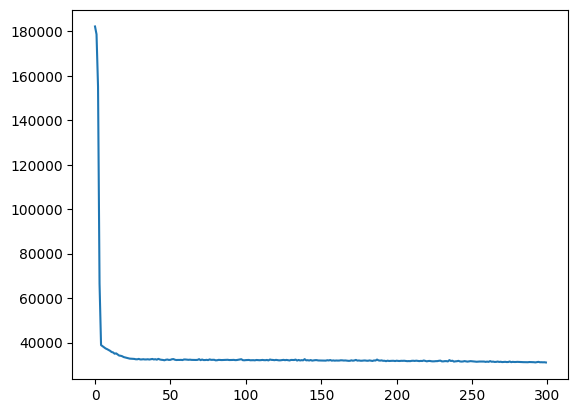

In [57]:
plt.plot(train_history.history["loss"])
plt.show()

In [61]:
model.evaluate(X_test, Y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28590.9590 


28590.958984375

In [ ]:
model.save("/content/drive/MyDrive/Machine Learning/Kaggle/house_price.h5")